# Olist case: единый ноутбук-решение

Итак, задача простая и практичная: понять, почему часть заказов получает 1-2 звезды, и на какие зоны риска бизнесу смотреть в первую очередь.

## Рабочие гипотезы
- `H1`: просрочка доставки повышает риск плохого отзыва.
- `H2`: чем дольше доставка, тем ниже оценка.
- `H3`: есть группа продавцов, которая дает непропорционально много late+bad заказов.

Дальше иду по шагам: сначала качество данных, потом витрины, затем метрики, графики, проверка гипотез и выводы для команды.

In [1]:
# Импорты и настройки вынесены в те ячейки,
# где они впервые реально используются.

## 1) Реляционный слой: загрузка в DuckDB

Сначала поднимаю локальную SQL-базу. Это нужно, чтобы расчеты были прозрачными: в любой момент можно открыть запрос и проверить, откуда взялась метрика.

In [2]:
from pathlib import Path

import duckdb
import pandas as pd

pd.set_option("display.max_columns", 200)

DATA_DIR = Path("data")
assert DATA_DIR.is_dir(), "Expected data/ folder with Olist CSV files"

con = duckdb.connect(":memory:")

# Для этого кейса нужны только таблицы, которые реально участвуют в расчетах.
TABLES = [
    ("orders", "olist_orders_dataset.csv"),
    ("order_items", "olist_order_items_dataset.csv"),
    ("payments", "olist_order_payments_dataset.csv"),
    ("reviews", "olist_order_reviews_dataset.csv"),
    ("customers", "olist_customers_dataset.csv"),
]

for table_name, csv_name in TABLES:
    csv_path = (DATA_DIR / csv_name).resolve().as_posix()
    con.execute(
        f"CREATE OR REPLACE TABLE {table_name} AS SELECT * FROM read_csv_auto(?, header=true)",
        [csv_path],
    )

pd.DataFrame(
    {
        "table": [t for t, _ in TABLES],
        "rows": [con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0] for t, _ in TABLES],
    }
)

,table,rows
0,orders,99441
1,order_items,112650
2,payments,103886
3,reviews,99224
4,customers,99441


## 1.1 Проверка качества данных

Перед расчетами проверяю базовую целостность: статусы заказов, пропуски дат и orphan-строки. Если этот шаг пропустить, дальше можно получить красивые, но неверные выводы.

In [3]:
status_df = con.execute(
    """
    SELECT order_status, COUNT(*) AS orders
    FROM orders
    GROUP BY 1
    ORDER BY orders DESC
    """
).df()

quality_df = con.execute(
    """
    SELECT
        COUNT(*) AS total_orders,
        SUM(CASE WHEN order_delivered_customer_date IS NULL THEN 1 ELSE 0 END) AS missing_delivered_at,
        SUM(CASE WHEN order_estimated_delivery_date IS NULL THEN 1 ELSE 0 END) AS missing_estimated_delivery,
        SUM(CASE WHEN order_status = 'delivered' THEN 1 ELSE 0 END) AS delivered_orders,
        SUM(CASE WHEN order_status = 'canceled' THEN 1 ELSE 0 END) AS canceled_orders
    FROM orders
    """
).df()

orphan_df = con.execute(
    """
    SELECT 'order_items' AS table_name, COUNT(*) AS orphan_rows
    FROM order_items i
    LEFT JOIN orders o ON o.order_id = i.order_id
    WHERE o.order_id IS NULL

    UNION ALL

    SELECT 'payments' AS table_name, COUNT(*) AS orphan_rows
    FROM payments p
    LEFT JOIN orders o ON o.order_id = p.order_id
    WHERE o.order_id IS NULL

    UNION ALL

    SELECT 'reviews' AS table_name, COUNT(*) AS orphan_rows
    FROM reviews r
    LEFT JOIN orders o ON o.order_id = r.order_id
    WHERE o.order_id IS NULL
    """
).df()

display(status_df)
display(quality_df)
display(orphan_df)

,order_status,orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


,total_orders,missing_delivered_at,missing_estimated_delivery,delivered_orders,canceled_orders
0,99441,2965.0,0.0,96478.0,625.0


,table_name,orphan_rows
0,order_items,0
1,payments,0
2,reviews,0


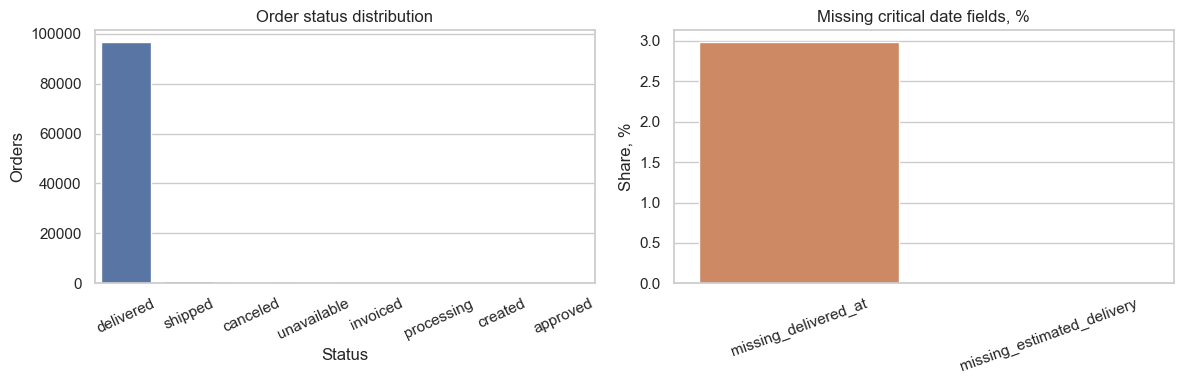

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=status_df, x="order_status", y="orders", color="#4C72B0", ax=axes[0])
axes[0].set_title("Order status distribution")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x", rotation=25)

missing_plot = pd.DataFrame(
    {
        "metric": ["missing_delivered_at", "missing_estimated_delivery"],
        "share_pct": [
            quality_df.loc[0, "missing_delivered_at"] / quality_df.loc[0, "total_orders"] * 100,
            quality_df.loc[0, "missing_estimated_delivery"] / quality_df.loc[0, "total_orders"] * 100,
        ],
    }
)
sns.barplot(data=missing_plot, x="metric", y="share_pct", color="#DD8452", ax=axes[1])
axes[1].set_title("Missing critical date fields, %")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share, %")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 2) Витрина заказов и базовые метрики

Собираю `v_order_facts` на уровне заказа. Это основа всего отчета: деньги, сроки, оценки и география.

На этом шаге важно увидеть общую картину: объем, GMV, долю просрочек. После этого уже понятно, куда идти глубже.

In [5]:
con.execute(
    """
    CREATE OR REPLACE VIEW v_order_facts AS
    WITH items AS (
        SELECT
            order_id,
            SUM(price + freight_value) AS gmv_items,
            COUNT(*) AS n_lines
        FROM order_items
        GROUP BY 1
    ),
    pays AS (
        SELECT
            order_id,
            SUM(payment_value) AS gmv_payments,
            MAX(payment_installments) AS max_installments
        FROM payments
        GROUP BY 1
    ),
    rev AS (
        SELECT
            order_id,
            AVG(review_score) AS review_score
        FROM reviews
        GROUP BY 1
    ),
    orders_typed AS (
        SELECT
            order_id,
            customer_id,
            order_status,
            CAST(order_purchase_timestamp AS TIMESTAMP) AS purchased_at,
            CAST(order_delivered_customer_date AS TIMESTAMP) AS delivered_at,
            CAST(order_estimated_delivery_date AS TIMESTAMP) AS estimated_delivery
        FROM orders
        WHERE order_status = 'delivered'
          AND order_delivered_customer_date IS NOT NULL
          AND order_estimated_delivery_date IS NOT NULL
    )
    SELECT
        o.order_id,
        o.customer_id,
        c.customer_state,
        o.purchased_at,
        o.delivered_at,
        o.estimated_delivery,
        i.gmv_items,
        p.gmv_payments,
        i.n_lines,
        p.max_installments,
        r.review_score,
        date_diff('day', o.purchased_at, o.delivered_at) AS delivery_days,
        CASE WHEN o.delivered_at > o.estimated_delivery THEN 1 ELSE 0 END AS is_late
    FROM orders_typed o
    JOIN customers c ON c.customer_id = o.customer_id
    LEFT JOIN items i ON i.order_id = o.order_id
    LEFT JOIN pays p ON p.order_id = o.order_id
    LEFT JOIN rev r ON r.order_id = o.order_id
    """
)

facts = con.execute("SELECT * FROM v_order_facts").df()
facts.head()

,order_id,customer_id,customer_state,purchased_at,delivered_at,estimated_delivery,gmv_items,gmv_payments,n_lines,max_installments,review_score,delivery_days,is_late
0,00276d5c3491fbf55305e26891040df9,54686c41e86854e35879efbd1c2cab1b,PR,2018-02-13 11:47:21,2018-03-16 19:57:52,2018-03-22,68.12,68.12,1,6,4.0,31,0
1,005d9a5423d47281ac463a968b3936fb,a2be07c22a9d2071f65b6770e47f540b,SP,2017-10-18 12:14:29,2017-10-27 19:19:43,2017-11-17,145.25,145.26,3,10,1.0,9,0
2,008819c6d5f6da6fa5cd9d50ca927cf4,f453853c7750dfea2b35f2a89382003e,SP,2018-08-04 21:40:35,2018-08-07 20:12:22,2018-08-09,62.65,62.65,1,2,3.0,3,0
3,00bdcdda88e6b02977fc6ce3d412c600,45ba03e2c6bbb5dc48131ba32ec3ae5e,RJ,2018-06-12 09:51:55,2018-06-18 18:20:48,2018-07-24,137.83,137.83,1,1,5.0,6,0
4,00ce92d57f4f9a112bdb8a2a283e5f97,9c1e141643cc2c164c2fa7c7140f5317,RJ,2018-01-30 16:20:19,2018-02-07 12:22:05,2018-02-26,189.37,189.37,1,2,5.0,8,0


,metric,value
0,"Orders (delivered, known dates)",9.647000e+04
1,GMV items sum,1.541839e+07
2,GMV payments sum,1.542108e+07
3,AOV items,1.598300e+02
4,"Late delivery share, %",8.110000e+00
5,Average review score,4.156000e+00


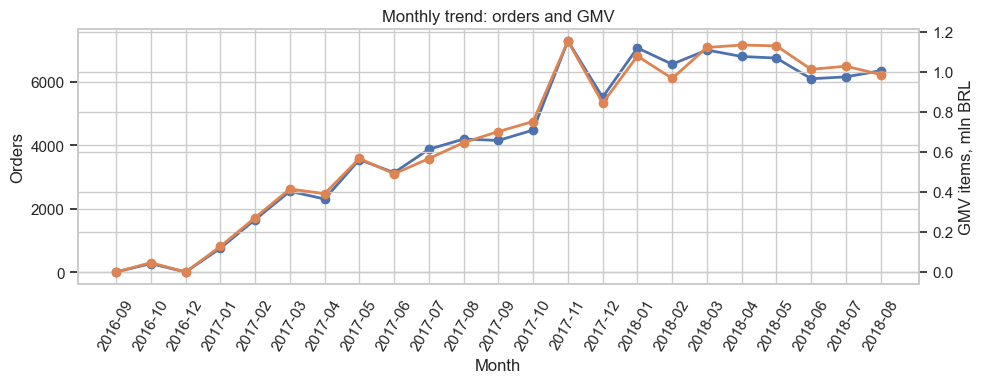

In [6]:
summary = pd.DataFrame(
    {
        "metric": [
            "Orders (delivered, known dates)",
            "GMV items sum",
            "GMV payments sum",
            "AOV items",
            "Late delivery share, %",
            "Average review score",
        ],
        "value": [
            len(facts),
            round(facts["gmv_items"].sum(), 2),
            round(facts["gmv_payments"].sum(), 2),
            round(facts["gmv_items"].mean(), 2),
            round(facts["is_late"].mean() * 100, 2),
            round(facts["review_score"].mean(skipna=True), 3),
        ],
    }
)
display(summary)

monthly = con.execute(
    """
    SELECT
        strftime(purchased_at, '%Y-%m') AS ym,
        COUNT(*) AS orders,
        SUM(gmv_items) AS gmv_items
    FROM v_order_facts
    GROUP BY 1
    ORDER BY 1
    """
).df()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(monthly["ym"], monthly["orders"], color="#4C72B0", marker="o", lw=2)
ax1.set_ylabel("Orders")
ax1.set_xlabel("Month")
ax1.tick_params(axis="x", rotation=60)

ax2 = ax1.twinx()
ax2.plot(monthly["ym"], monthly["gmv_items"] / 1e6, color="#DD8452", marker="o", lw=2)
ax2.set_ylabel("GMV items, mln BRL")

ax1.set_title("Monthly trend: orders and GMV")
plt.tight_layout()
plt.show()

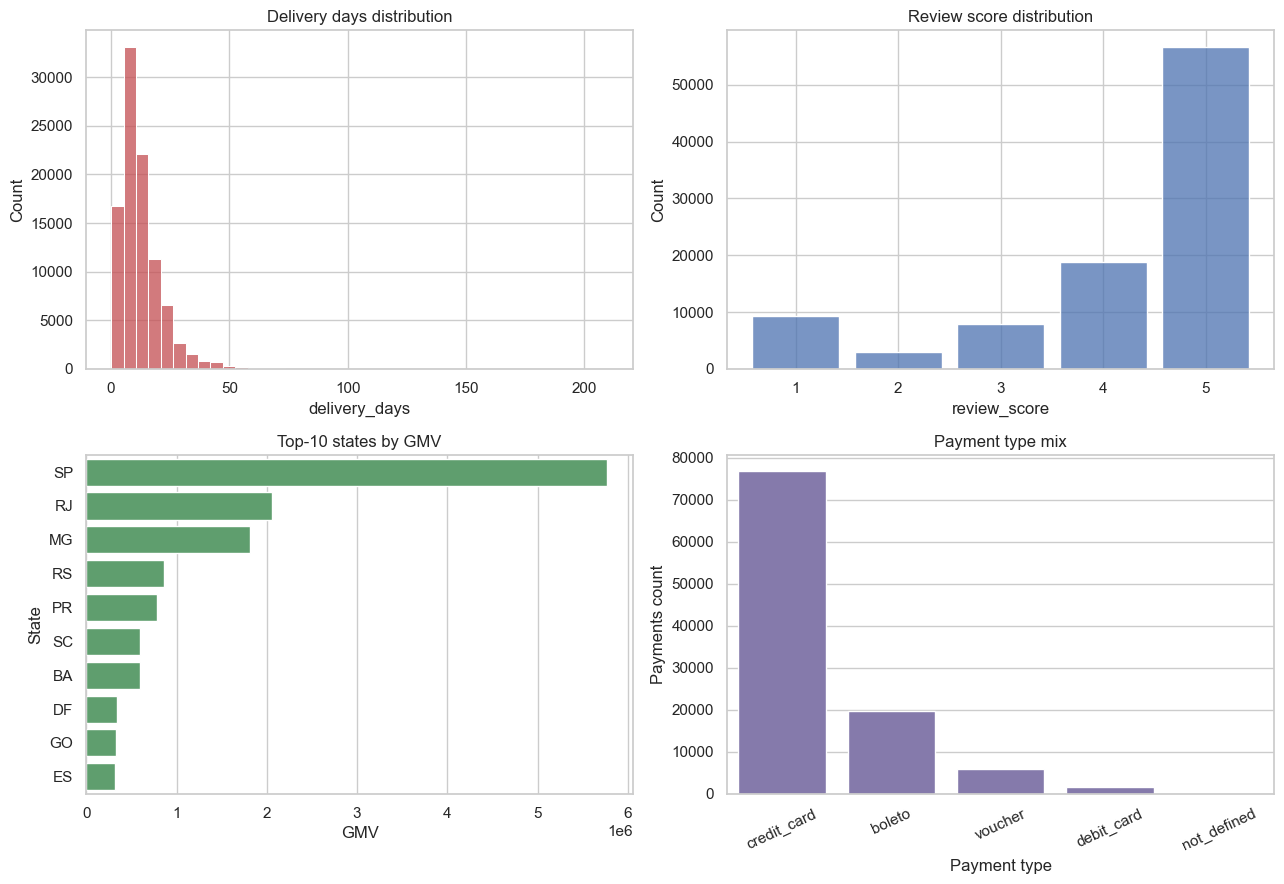

In [7]:
state_gmv = con.execute(
    """
    SELECT customer_state, SUM(gmv_items) AS gmv_items
    FROM v_order_facts
    GROUP BY 1
    ORDER BY gmv_items DESC
    LIMIT 10
    """
).df()

payment_mix = con.execute(
    """
    SELECT payment_type, COUNT(*) AS payments
    FROM payments
    GROUP BY 1
    ORDER BY payments DESC
    """
).df()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(data=facts, x="delivery_days", bins=40, kde=False, color="#C44E52", ax=axes[0, 0])
axes[0, 0].set_title("Delivery days distribution")

sns.histplot(data=facts.dropna(subset=["review_score"]), x="review_score", discrete=True, shrink=0.85, color="#4C72B0", ax=axes[0, 1])
axes[0, 1].set_title("Review score distribution")

sns.barplot(data=state_gmv, y="customer_state", x="gmv_items", color="#55A868", ax=axes[1, 0])
axes[1, 0].set_title("Top-10 states by GMV")
axes[1, 0].set_xlabel("GMV")
axes[1, 0].set_ylabel("State")

sns.barplot(data=payment_mix, x="payment_type", y="payments", color="#8172B3", ax=axes[1, 1])
axes[1, 1].set_title("Payment type mix")
axes[1, 1].set_xlabel("Payment type")
axes[1, 1].set_ylabel("Payments count")
axes[1, 1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 3) Целевая витрина кейса: отзывы, задержки, продавцы

Здесь перехожу к основной задаче кейса. Собираю `v_case_order_base` со всеми признаками, которые нужны для проверки гипотез.

Метрики оставляю простыми и понятными: `bad_review_flag`, `is_late`, `delay_days`. Так их легче обсуждать с бизнесом.

In [8]:
con.execute(
    """
    CREATE OR REPLACE VIEW v_case_order_base AS
    WITH review_per_order AS (
        SELECT order_id, AVG(review_score) AS review_score
        FROM reviews
        GROUP BY 1
    ),
    seller_order_value AS (
        SELECT order_id, seller_id, SUM(price + freight_value) AS seller_value
        FROM order_items
        GROUP BY 1, 2
    ),
    primary_seller AS (
        SELECT
            order_id,
            seller_id,
            ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY seller_value DESC, seller_id) AS rn
        FROM seller_order_value
    )
    SELECT
        f.order_id,
        f.purchased_at,
        f.estimated_delivery,
        f.delivered_at,
        date_diff('day', f.estimated_delivery, f.delivered_at) AS delay_days,
        r.review_score,
        CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END AS bad_review_flag,
        f.is_late,
        ps.seller_id AS primary_seller_id
    FROM v_order_facts f
    JOIN review_per_order r ON r.order_id = f.order_id
    LEFT JOIN primary_seller ps ON ps.order_id = f.order_id AND ps.rn = 1
    WHERE r.review_score IS NOT NULL
    """
)

case_preview = con.execute(
    """
    SELECT order_id, delay_days, review_score, bad_review_flag, is_late, primary_seller_id
    FROM v_case_order_base
    LIMIT 5
    """
).df()
display(case_preview)

kpi_case = con.execute(
    """
    SELECT
        COUNT(*) AS orders,
        AVG(bad_review_flag) AS bad_review_rate,
        AVG(is_late) AS late_rate,
        AVG(delay_days) AS avg_delay_days,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY delay_days) AS median_delay_days
    FROM v_case_order_base
    """
).df()
display(kpi_case)

delay_bucket = con.execute(
    """
    SELECT
        CASE
            WHEN delay_days <= -3 THEN 'Early (>=3 days)'
            WHEN delay_days BETWEEN -2 AND 0 THEN 'On time / slightly early'
            WHEN delay_days BETWEEN 1 AND 3 THEN 'Late 1-3 days'
            ELSE 'Late 4+ days'
        END AS delay_bucket,
        COUNT(*) AS orders,
        AVG(bad_review_flag) AS bad_review_rate,
        AVG(is_late) AS late_rate,
        AVG(delay_days) AS avg_delay_days
    FROM v_case_order_base
    GROUP BY 1
    ORDER BY avg_delay_days
    """
).df()
delay_bucket

,order_id,delay_days,review_score,bad_review_flag,is_late,primary_seller_id
0,fa9bb0fcd9ac91743999d13c2860dac5,-14,5.0,0,0,17f51e7198701186712e53a39c564617
1,fa9ef315051f18a68686aca274ae8f2a,-17,5.0,0,0,4a3ca9315b744ce9f8e9374361493884
2,faa1515e28c5d45a5bb6fa57bffcfb0b,-29,5.0,0,0,e6a69c4a27dfdd98ffe5aa757ad744bc
3,faa656e714039086ed78afa051133804,-15,3.0,0,0,5058e8c1e82653974541e83690655b4a
4,fab5dff71a23a54ed252a564cbfd4826,-9,4.0,0,0,7a67c85e85bb2ce8582c35f2203ad736


,orders,bad_review_rate,late_rate,avg_delay_days,median_delay_days
0,95824,0.127692,0.079949,-11.91307,-12.0


,delay_bucket,orders,bad_review_rate,late_rate,avg_delay_days
0,Early (>=3 days),85173,0.091120,0.000000,-14.137649
1,On time / slightly early,4270,0.116159,0.299766,-1.060890
2,Late 1-3 days,1852,0.321814,1.000000,1.825054
3,Late 4+ days,4529,0.746964,1.000000,14.073305


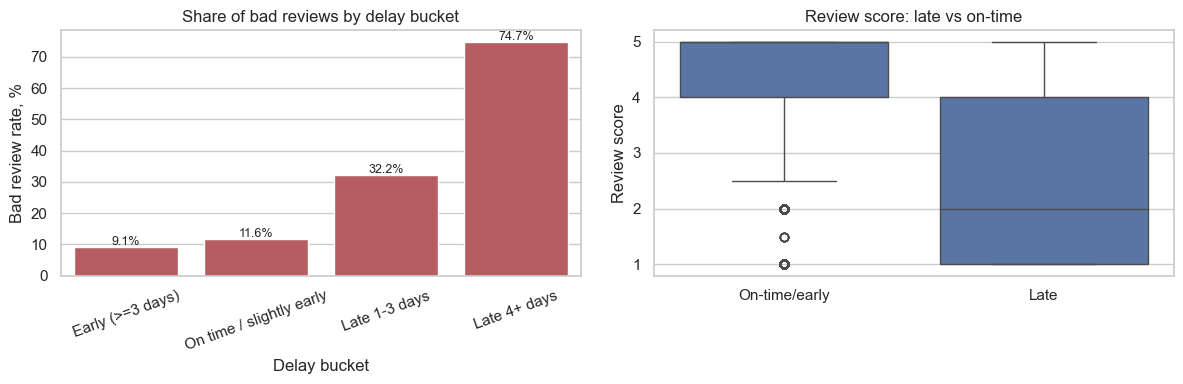

In [9]:
plot_df = delay_bucket.copy()
plot_df["bad_review_rate_pct"] = plot_df["bad_review_rate"] * 100

review_by_late = con.execute(
    """
    SELECT
        CASE WHEN is_late = 1 THEN 'Late' ELSE 'On-time/early' END AS delivery_group,
        review_score
    FROM v_case_order_base
    """
).df()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=plot_df, x="delay_bucket", y="bad_review_rate_pct", color="#C44E52", ax=axes[0])
axes[0].set_xlabel("Delay bucket")
axes[0].set_ylabel("Bad review rate, %")
axes[0].set_title("Share of bad reviews by delay bucket")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(plot_df["bad_review_rate_pct"]):
    axes[0].text(i, v + 0.7, f"{v:.1f}%", ha="center", fontsize=9)

sns.boxplot(data=review_by_late, x="delivery_group", y="review_score", color="#4C72B0", ax=axes[1])
axes[1].set_title("Review score: late vs on-time")
axes[1].set_xlabel("")
axes[1].set_ylabel("Review score")

plt.tight_layout()
plt.show()

## 4) Поиск зон риска: анализ продавцов

Практический шаг для бизнеса здесь один: выделить продавцов, у которых одновременно высокие `late_rate` и `bad_review_rate`.

Это дает понятный shortlist для операционной команды и экономит время: не нужно сразу пытаться исправить весь рынок.

Sellers with >=50 orders: 413
Risk sellers (above benchmark on both metrics): 114


,seller_id,orders,bad_review_rate,late_rate,avg_delay_days
0,1ca7077d890b907f89be8c954a02686a,107,0.598131,0.214953,-6.728972
1,2eb70248d66e0e3ef83659f71b244378,183,0.475410,0.136612,-10.032787
2,972d0f9cf61b499a4812cf0bfa3ad3c4,78,0.410256,0.115385,-9.500000
3,a49928bcdf77c55c6d6e05e09a9b4ca5,96,0.406250,0.260417,-4.447917
4,54965bbe3e4f07ae045b90b0b8541f52,69,0.405797,0.289855,-3.739130
5,bbad7e518d7af88a0897397ffdca1979,64,0.375000,0.171875,-9.062500
6,6fd52c528dcb38be2eea044946b811f8,66,0.363636,0.136364,-10.772727
7,712e6ed8aa4aa1fa65dab41fed5737e4,76,0.355263,0.210526,-9.684211
10,88460e8ebdecbfecb5f9601833981930,231,0.290043,0.203463,-10.861472
11,5058e8c1e82653974541e83690655b4a,59,0.288136,0.135593,-15.847458


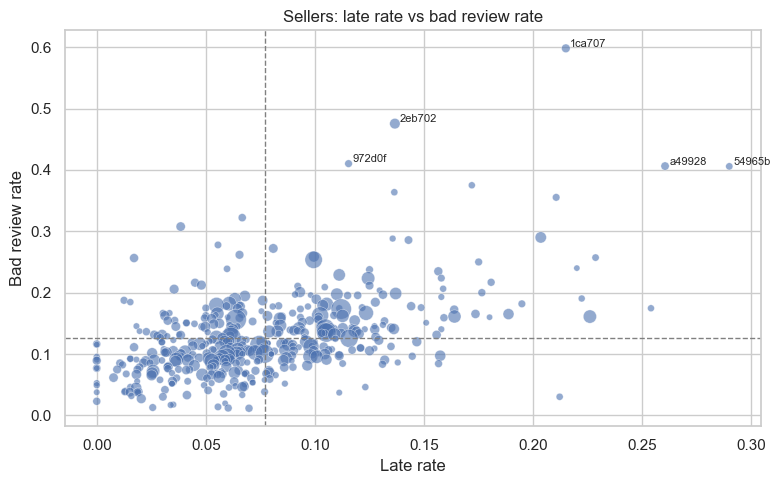

,total_case_orders,total_late_bad_orders,late_bad_orders_from_risk_sellers,risk_share_of_late_bad_pct
0,95824,4136.0,1539.0,37.209865


In [10]:
import numpy as np

seller_perf = con.execute(
    """
    WITH seller_stats AS (
        SELECT
            primary_seller_id AS seller_id,
            COUNT(*) AS orders,
            AVG(bad_review_flag) AS bad_review_rate,
            AVG(is_late) AS late_rate,
            AVG(delay_days) AS avg_delay_days
        FROM v_case_order_base
        WHERE primary_seller_id IS NOT NULL
        GROUP BY 1
    )
    SELECT *
    FROM seller_stats
    WHERE orders >= 50
    ORDER BY bad_review_rate DESC, late_rate DESC
    """
).df()

bench_bad = seller_perf["bad_review_rate"].mean()
bench_late = seller_perf["late_rate"].mean()

risk_sellers = seller_perf[
    (seller_perf["bad_review_rate"] > bench_bad)
    & (seller_perf["late_rate"] > bench_late)
].sort_values(["bad_review_rate", "late_rate"], ascending=False)

print(f"Sellers with >=50 orders: {len(seller_perf)}")
print(f"Risk sellers (above benchmark on both metrics): {len(risk_sellers)}")
display(risk_sellers.head(10))

viz_df = seller_perf.assign(orders_size=np.sqrt(seller_perf["orders"]) * 7)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=viz_df,
    x="late_rate",
    y="bad_review_rate",
    size="orders_size",
    sizes=(20, 220),
    alpha=0.6,
    legend=False,
    ax=ax,
)
ax.axvline(bench_late, color="gray", linestyle="--", linewidth=1)
ax.axhline(bench_bad, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Late rate")
ax.set_ylabel("Bad review rate")
ax.set_title("Sellers: late rate vs bad review rate")

for _, row in risk_sellers.head(5).iterrows():
    ax.text(row["late_rate"] + 0.002, row["bad_review_rate"] + 0.002, row["seller_id"][:6], fontsize=8)

plt.tight_layout()
plt.show()

con.register("risk_sellers", risk_sellers[["seller_id"]])
risk_impact = con.execute(
    """
    WITH risk_ids AS (
        SELECT seller_id FROM risk_sellers
    )
    SELECT
        COUNT(*) AS total_case_orders,
        SUM(CASE WHEN is_late = 1 AND bad_review_flag = 1 THEN 1 ELSE 0 END) AS total_late_bad_orders,
        SUM(
            CASE
                WHEN is_late = 1
                     AND bad_review_flag = 1
                     AND primary_seller_id IN (SELECT seller_id FROM risk_ids)
                THEN 1 ELSE 0
            END
        ) AS late_bad_orders_from_risk_sellers
    FROM v_case_order_base
    """
).df()
risk_impact["risk_share_of_late_bad_pct"] = (
    risk_impact["late_bad_orders_from_risk_sellers"] / risk_impact["total_late_bad_orders"] * 100
)

display(risk_impact)

## 5) Проверка гипотез (матстатистика)

Дальше проверяю, насколько эффект устойчив статистически:
- late-факт и плохой отзыв (хи-квадрат);
- длительность доставки и оценка (Spearman);
- быстрые vs долгие доставки (Mann-Whitney).

Плюс смотрю квартили задержки, чтобы понять, как растет риск по мере ухудшения сроков.

bad_review_flag      0     1
is_late                     
0                80063  8100
1                 3525  4136
chi2 = 12696.53, p-value = 0.000e+00, dof = 1


bad_review_rate late orders: 53.988%
bad_review_rate on-time/early orders: 9.188%
Spearman rho = -0.2351, p-value = 0.00e+00
Mann-Whitney p-value (<=7 vs >14 days): 0.00e+00
Median review (<=7 days): 5.00 | (>14 days): 4.00


,delay_quartile,orders,bad_review_rate
0,1,23956,0.093839
1,2,23956,0.084446
2,3,23956,0.090165
3,4,23956,0.242319


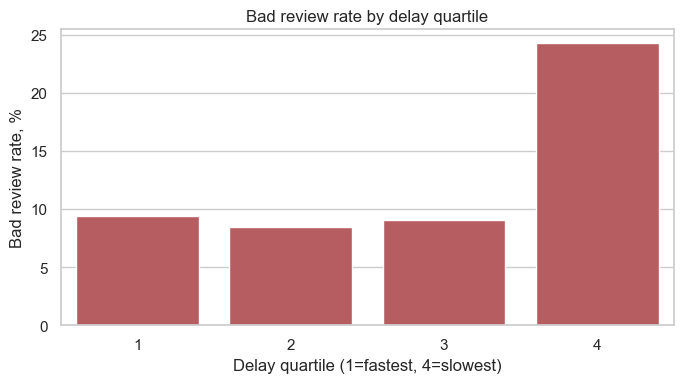

In [11]:
from scipy import stats
from scipy.stats import chi2_contingency

ct = con.execute(
    """
    SELECT is_late, bad_review_flag, COUNT(*) AS n
    FROM v_case_order_base
    GROUP BY 1, 2
    ORDER BY 1, 2
    """
).df()

pivot = ct.pivot_table(index="is_late", columns="bad_review_flag", values="n", fill_value=0).astype(int)
chi2, p_value, dof, expected = chi2_contingency(pivot)

print(pivot)
print(f"chi2 = {chi2:.2f}, p-value = {p_value:.3e}, dof = {dof}")

rates = con.execute(
    """
    SELECT is_late, AVG(bad_review_flag) AS bad_review_rate
    FROM v_case_order_base
    GROUP BY 1
    ORDER BY 1 DESC
    """
).df()

late_bad = rates.loc[rates["is_late"] == 1, "bad_review_rate"].iloc[0]
ontime_bad = rates.loc[rates["is_late"] == 0, "bad_review_rate"].iloc[0]
print(f"bad_review_rate late orders: {late_bad:.3%}")
print(f"bad_review_rate on-time/early orders: {ontime_bad:.3%}")

review_delivery = con.execute(
    "SELECT delivery_days, review_score FROM v_order_facts WHERE review_score IS NOT NULL"
).df()
rho, p_sp = stats.spearmanr(review_delivery["delivery_days"], review_delivery["review_score"])
print(f"Spearman rho = {rho:.4f}, p-value = {p_sp:.2e}")

fast = review_delivery.loc[review_delivery["delivery_days"] <= 7, "review_score"]
slow = review_delivery.loc[review_delivery["delivery_days"] > 14, "review_score"]
u_stat, p_mw = stats.mannwhitneyu(fast, slow, alternative="two-sided")
print(f"Mann-Whitney p-value (<=7 vs >14 days): {p_mw:.2e}")
print(f"Median review (<=7 days): {fast.median():.2f} | (>14 days): {slow.median():.2f}")

quantile_effect = con.execute(
    """
    WITH q AS (
        SELECT
            delay_days,
            bad_review_flag,
            NTILE(4) OVER (ORDER BY delay_days) AS delay_quartile
        FROM v_case_order_base
    )
    SELECT delay_quartile, COUNT(*) AS orders, AVG(bad_review_flag) AS bad_review_rate
    FROM q
    GROUP BY 1
    ORDER BY 1
    """
).df()

display(quantile_effect)

quantile_plot = quantile_effect.copy()
quantile_plot["bad_review_rate_pct"] = quantile_plot["bad_review_rate"] * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=quantile_plot, x="delay_quartile", y="bad_review_rate_pct", color="#C44E52", ax=ax)
ax.set_title("Bad review rate by delay quartile")
ax.set_xlabel("Delay quartile (1=fastest, 4=slowest)")
ax.set_ylabel("Bad review rate, %")
plt.tight_layout()
plt.show()

## 6) Выводы по результатам прогона

### Что видно по цифрам
- Плохие отзывы при просрочке: **53.99%**.
- Плохие отзывы при доставке вовремя/раньше: **9.19%**.
- Разница почти в **5.9 раза**.
- По продавцам (`orders >= 50`): **413** продавцов, из них **114** в risk-группе.
- Статтесты подтверждают, что эффект устойчив: `chi2`, Spearman и Mann-Whitney значимы.

### Как я это читаю
Гипотезы `H1`, `H2`, `H3` подтвердились. Логистика и соблюдение SLA заметно связаны с оценкой клиента, а риск концентрируется в части продавцов.

### Что делать дальше
1. Вести еженедельный мониторинг `risk_sellers`.
2. Для top-risk продавцов запустить короткий операционный план: контроль отгрузки, SLA, коммуникация с логистикой.
3. Через 4-6 недель пересчитать тот же срез и проверить динамику `late+bad`.

### Ограничения
- В заказе может быть несколько продавцов; здесь используется `primary_seller`.
- Это наблюдательный анализ: он показывает связь, но причинность нужно проверять отдельным дизайном.

## 7) Что проверить в следующей итерации

На следующем шаге беру только две гипотезы, чтобы не распыляться:

- `H4`: в штатах с более высоким `late_rate` обычно выше `bad_review_rate`.
- `H5`: у заказов с большим числом платежей (`installments`) риск негатива выше.

Это не финальные выводы, а рабочий скрининг перед более глубоким анализом.

State-level corr(late_rate, bad_review_rate): 0.877


,installments_group,orders,late_rate,bad_review_rate
0,1-3,68531,0.078738,0.121930
1,4-7,17177,0.081330,0.134715
2,8+,10116,0.085805,0.154804


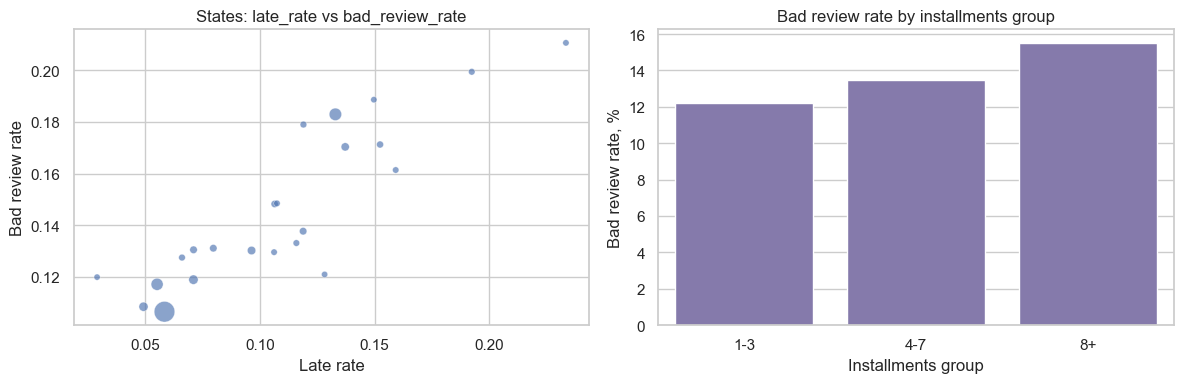

In [12]:
state_check = con.execute(
    """
    WITH st AS (
        SELECT
            customer_state,
            AVG(is_late) AS late_rate,
            AVG(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) AS bad_review_rate,
            COUNT(*) AS orders
        FROM v_order_facts
        WHERE review_score IS NOT NULL
        GROUP BY 1
        HAVING COUNT(*) >= 200
    )
    SELECT *
    FROM st
    ORDER BY orders DESC
    """
).df()

state_corr = state_check[["late_rate", "bad_review_rate"]].corr().iloc[0, 1]
print(f"State-level corr(late_rate, bad_review_rate): {state_corr:.3f}")

installment_check = con.execute(
    """
    SELECT
        CASE
            WHEN max_installments >= 8 THEN '8+'
            WHEN max_installments BETWEEN 4 AND 7 THEN '4-7'
            ELSE '1-3'
        END AS installments_group,
        COUNT(*) AS orders,
        AVG(is_late) AS late_rate,
        AVG(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) AS bad_review_rate
    FROM v_order_facts
    WHERE review_score IS NOT NULL
    GROUP BY 1
    ORDER BY 1
    """
).df()

display(installment_check)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=state_check, x="late_rate", y="bad_review_rate", size="orders", sizes=(20, 220), alpha=0.65, legend=False, ax=axes[0])
axes[0].set_title("States: late_rate vs bad_review_rate")
axes[0].set_xlabel("Late rate")
axes[0].set_ylabel("Bad review rate")

plot_inst = installment_check.copy()
plot_inst["bad_review_rate_pct"] = plot_inst["bad_review_rate"] * 100
sns.barplot(data=plot_inst, x="installments_group", y="bad_review_rate_pct", color="#8172B3", ax=axes[1])
axes[1].set_title("Bad review rate by installments group")
axes[1].set_xlabel("Installments group")
axes[1].set_ylabel("Bad review rate, %")

plt.tight_layout()
plt.show()

## 8) Как проверить причинность: A/B или до/после

### A/B пилот (если можем запустить)

Идея простая: делим риск-продавцов на две группы.
- `Control`: работаем как обычно.
- `Test`: добавляем операционные меры (SLA-напоминания, быстрые эскалации, proactive-уведомления клиенту).

Главная метрика:
- `late_bad_rate` = доля заказов, где одновременно `is_late = 1` и `bad_review_flag = 1`.

Дополнительно смотрим:
- `late_rate`, `bad_review_rate`, `avg_delay_days`.

Срок пилота: 4-6 недель.  
Успех: `late_bad_rate` снижается в тесте, при этом GMV и число заказов не проседают.

### Если A/B нельзя

Тогда делаем дизайн до/после:
- группа с внедренными мерами;
- похожая контрольная группа без мер.

Сравниваем изменение `late_bad_rate` между группами. Если улучшение в группе с мерами заметно больше, это аргумент в пользу причинного эффекта.

### Практический план

1. Зафиксировать baseline KPI по risk-продавцам за 8 недель.
2. Выбрать дизайн: A/B или до/после + контроль.
3. Собирать weekly seller KPI и через 4-6 недель принять решение о масштабировании.

Ключевая мысль: текущий анализ показал сильную связь. Этот блок нужен, чтобы аккуратно проверить причинность.